# Convolutional Neural Networks zur Klassifikation von EMNIST-Klassen

## Persönliche Daten
Name: Lennart Materna

Studiengang: Mathematik

### Library imports

In [1]:
# imports for data handling, network definition, and training
import numpy as np
import torch
from torch import nn

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import sklearn
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE

## Choose GPU device if available

In [2]:
# choose gpu device if available, otherwise cpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## Classes contained in EMNIST dataset ('byclass' option)

In [3]:
# EMNIST classes in the correct order
# the class labels in the original dataset (byclass option) correspond to the position
# in the subsequent list; e.g. 'M' --> 22, 'b' --> 37, etc.
EMNIST_CLASSES = ['0','1','2','3','4','5','6','7','8','9', # digits
                  'A','B','C','D','E','F','G','H','I','J','K','L','M', # uppercase letters
                  'N','O','P','Q','R','S','T','U','V','W','X','Y','Z', 
                  'a','b','c','d','e','f','g','h','i','j','k','l','m', # lowercase letters
                  'n','o','p','q','r','s','t','u','v','w','x','y','z']

## Task a) Classes of individual homework assignment 

In [ ]:
from torchvision.datasets import EMNIST
dataset = EMNIST(root="data", split="byclass", train=True, download=True)

for symbol in ['0', '3', '5', '9', 'L', 'M', 'a', 'e', 'n', 'r', 't']:
    print(f"{symbol}: {dataset.class_to_idx[symbol]}") 

0: 0
3: 3
5: 5
9: 9
L: 21
M: 22
a: 36
e: 40
n: 49
r: 53
t: 55


## Task b)  EMNIST data import ('byclass' option) and extraction of balanced, customized datasets

In [ ]:
# EMNIST data import

# read EMNIST training data
train_data = datasets.EMNIST(
    root= './data/', # path of EMNIST data
    #split="letters",
    split="byclass",
    train=True,
    download=False,
    transform=ToTensor())

# read EMNIST test/validation data
val_data = datasets.EMNIST(
    root='./data/', # path of EMNIST data
    #split="letters",
    split="byclass",
    train=False,
    download=False,
    transform=ToTensor())

# "The function torch.utils.data.Subset(...) is suitable to implement the required data extraction."
from torch.utils.data import Subset

selected_symbols = ['0', '3', '5', '9', 'L', 'M', 'a', 'e', 'n', 'r', 't']
selected_classes = [0, 3, 5, 9, 21, 22, 36, 40, 49, 53, 55]

# Indiziere die Klassen aus der individuellen Teilmenge beginnend bei Index 0 (Relabeling)
label_map = {old: new for new, old in enumerate(selected_classes)}
print(label_map)

train_targets = train_data.targets
train_indices = {}
train_counts = {}

for c in selected_classes:
    idx = (train_targets == c).nonzero(as_tuple=True)[0]
    train_indices[c] = idx
    train_counts[c] = len(idx)

# "Determine and report for the loaded training dataset the number of sample images for each class of your individual subset of classes."
print("Training samples per class:")
for s, c in zip(selected_symbols, selected_classes):
    print(f"{s:2} ({c:2}) : {train_counts[c]}")

# "Use this information to extract a balanced training dataset of maximum total size for your individual subset of classes."
min_train = min(train_counts.values())
balanced_train_indices = []

for c in selected_classes:
    balanced_train_indices.extend(train_indices[c][:min_train])

balanced_train = Subset(train_data, balanced_train_indices)
print("Balanced training dataset size:", len(balanced_train))

# "Repeat these steps separately for the testing/validation dataset." (analog zu oben)
val_targets = val_data.targets
val_indices = {}
val_counts = {}

for c in selected_classes:
    idx = (val_targets == c).nonzero(as_tuple=True)[0]
    val_indices[c] = idx
    val_counts[c] = len(idx)

print("\nValidation samples per class:")
for s, c in zip(selected_symbols, selected_classes):
    print(f"{s:2} ({c:2}) : {val_counts[c]}")

min_val = min(val_counts.values())
balanced_val_indices = []

for c in selected_classes:
    balanced_val_indices.extend(val_indices[c][:min_val])

balanced_val = Subset(val_data, balanced_val_indices)
print("Balanced validation dataset size:", len(balanced_val))

# Relabeling:
from torch.utils.data import Dataset

class RelabeledDataset(Dataset):

    def __init__(self, subset, label_map):
        self.subset = subset
        self.label_map = label_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return image, self.label_map[label]

train_dataset = RelabeledDataset(balanced_train, label_map)
val_dataset = RelabeledDataset(balanced_val, label_map)

{0: 0, 3: 1, 5: 2, 9: 3, 21: 4, 22: 5, 36: 6, 40: 7, 49: 8, 53: 9, 55: 10}
Training samples per class:
0  ( 0) : 34585
3  ( 3) : 35143
5  ( 5) : 31416
9  ( 9) : 33847
L  (21) : 5076
M  (22) : 9002
a  (36) : 10033
e  (40) : 24631
n  (49) : 11418
r  (53) : 14105
t  (55) : 18262
Balanced training dataset size: 55836

Validation samples per class:
0  ( 0) : 5778
3  ( 3) : 5969
5  ( 5) : 5190
9  ( 9) : 5686
L  (21) : 810
M  (22) : 1485
a  (36) : 1644
e  (40) : 4092
n  (49) : 1898
r  (53) : 2320
t  (55) : 2965
Balanced validation dataset size: 8910


#### Discussion of relevance of balanced datasets
Eine ausgewogene Datenmenge (balanced dataset) enthält für jede einzelne Klasse (ungefähr) die gleiche Anzahl an training samples. Dadurch wird verhindert, dass das neuronale Netzwerk Klassen mit vielen Trainingsdaten bevorzugt. Bei einem unausgewogenen Datensatz könnte das CNN trotz einer schlechten Klassifikationsleistung für die unterrepräsentierten Klassen dennoch insgesamt eine hohe Gesamtgenauigkeit erreichen, indem es überwiegend die überrepräsentierten Klassen richtig klassifiziert.

## Task c): Visualization of sample images for each selected class

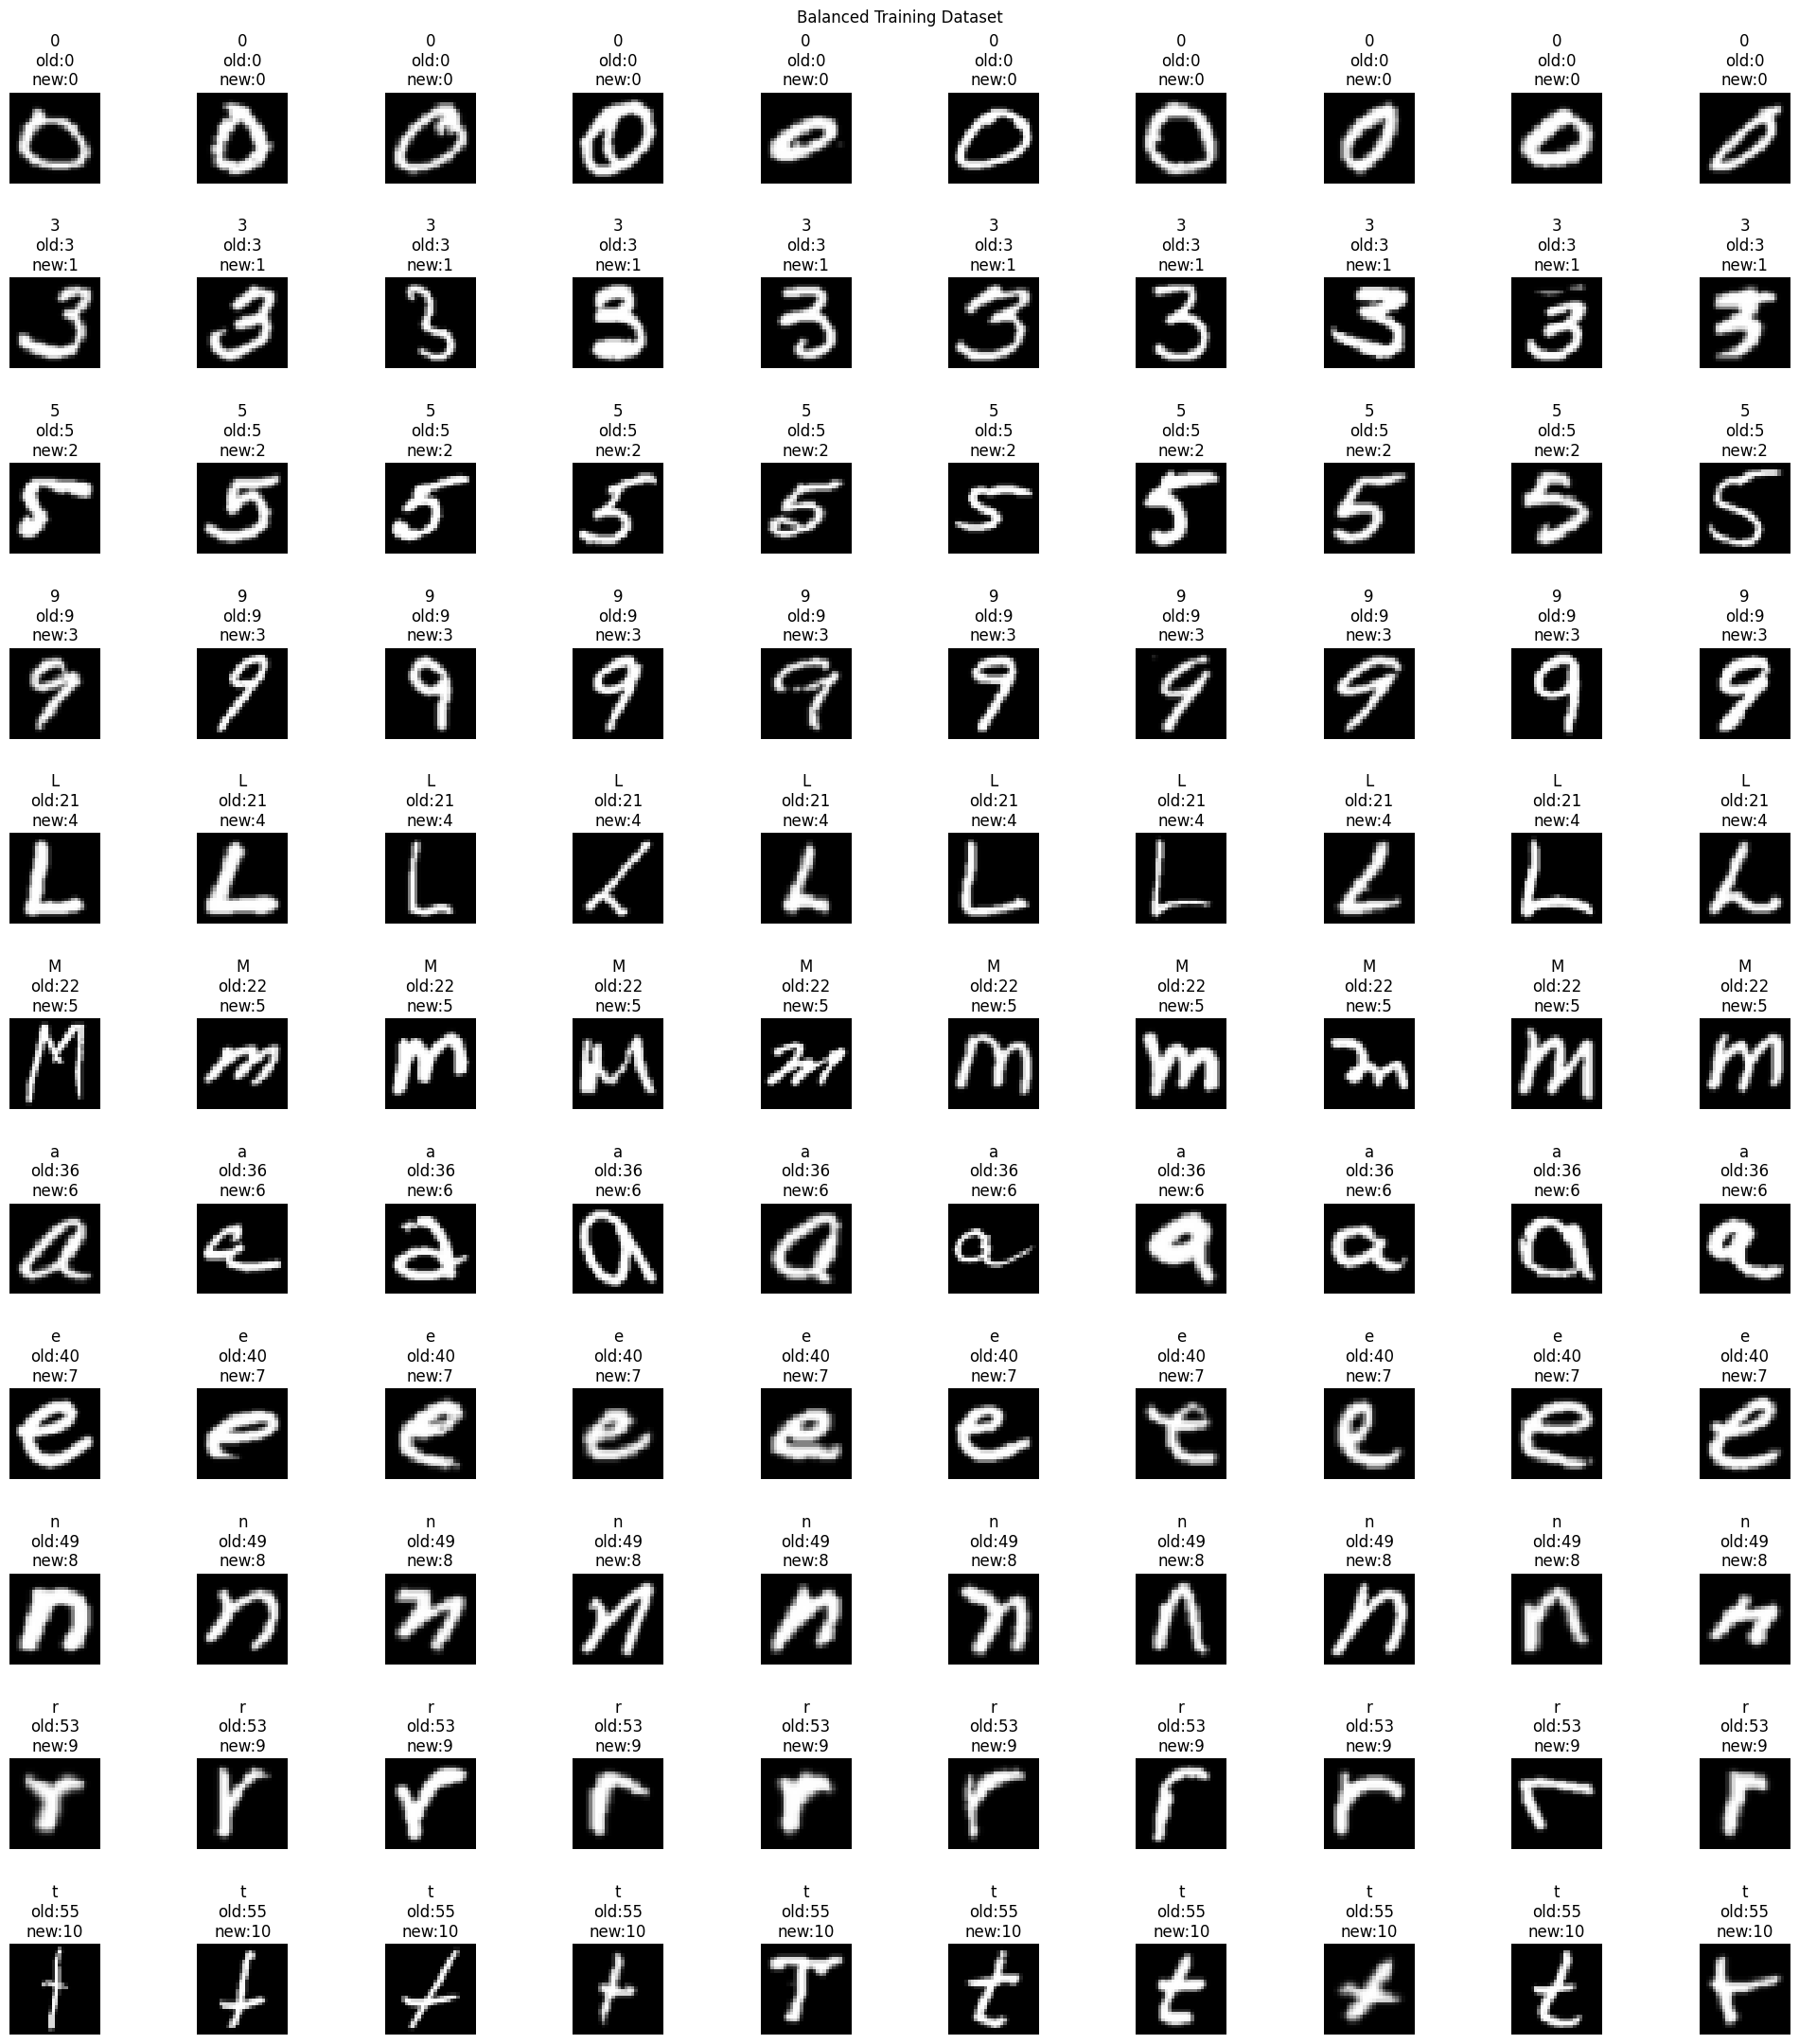

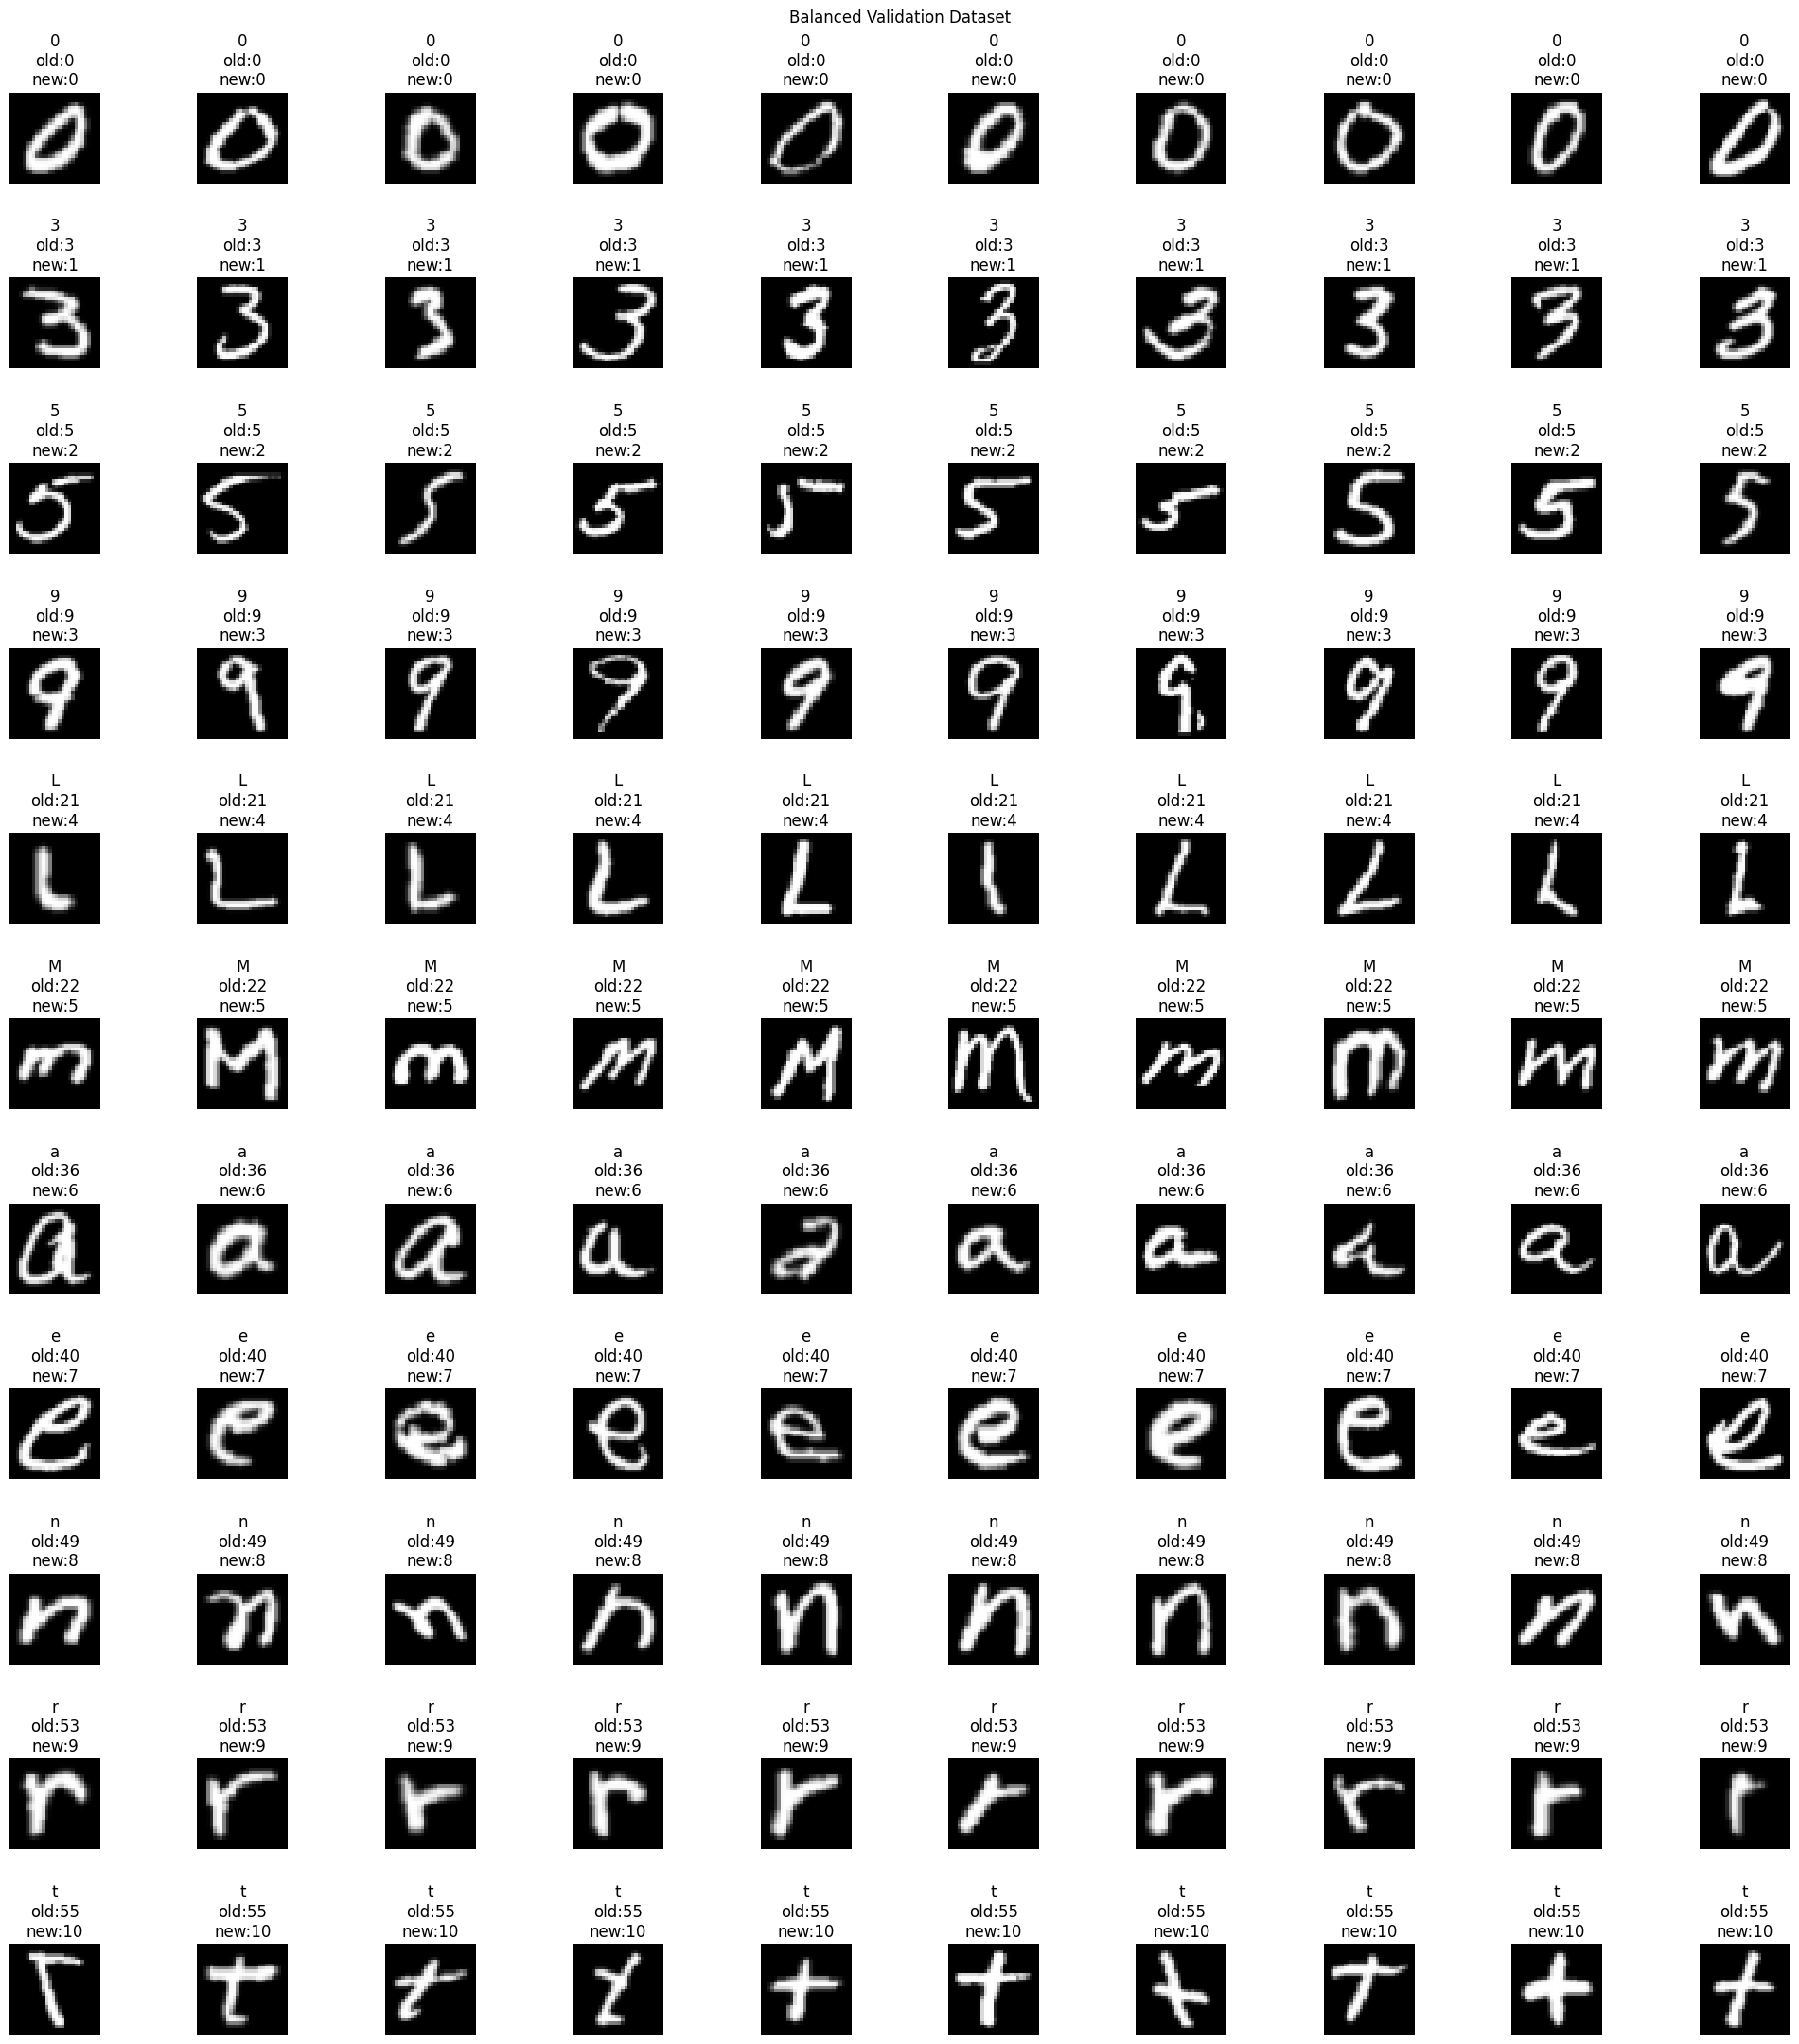

In [6]:
def show_samples(dataset, symbols, label_map, title, samples_per_class=10):

    fig, axes = plt.subplots(len(symbols), samples_per_class, figsize=(samples_per_class*2, len(symbols)*2))
    shown = {i: 0 for i in range(len(symbols))}

    for image, new_label in dataset:

        if shown[new_label] >= samples_per_class:
            continue

        row = new_label
        col = shown[new_label]
        img = image.squeeze()

        # "Note: To display the images of the considered dataset correctly they need to be 'transposed' (horizontal flip and then 90-degrees-anti-clockwise rotation)."
        img = torch.rot90(torch.fliplr(img), k=1)

        axes[row, col].imshow(img, cmap="gray")
        original_label = selected_classes[new_label]
        axes[row, col].set_title(f"\n{symbols[new_label]}\nold:{original_label}\nnew:{new_label}")
        axes[row, col].axis("off")
        shown[new_label] += 1

        if all(v == samples_per_class for v in shown.values()):
            break

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(train_dataset, selected_symbols, label_map, "Balanced Training Dataset")
show_samples(val_dataset, selected_symbols, label_map, "Balanced Validation Dataset")

## Task d): Layer dimensions, calculation of number trainable parameters 
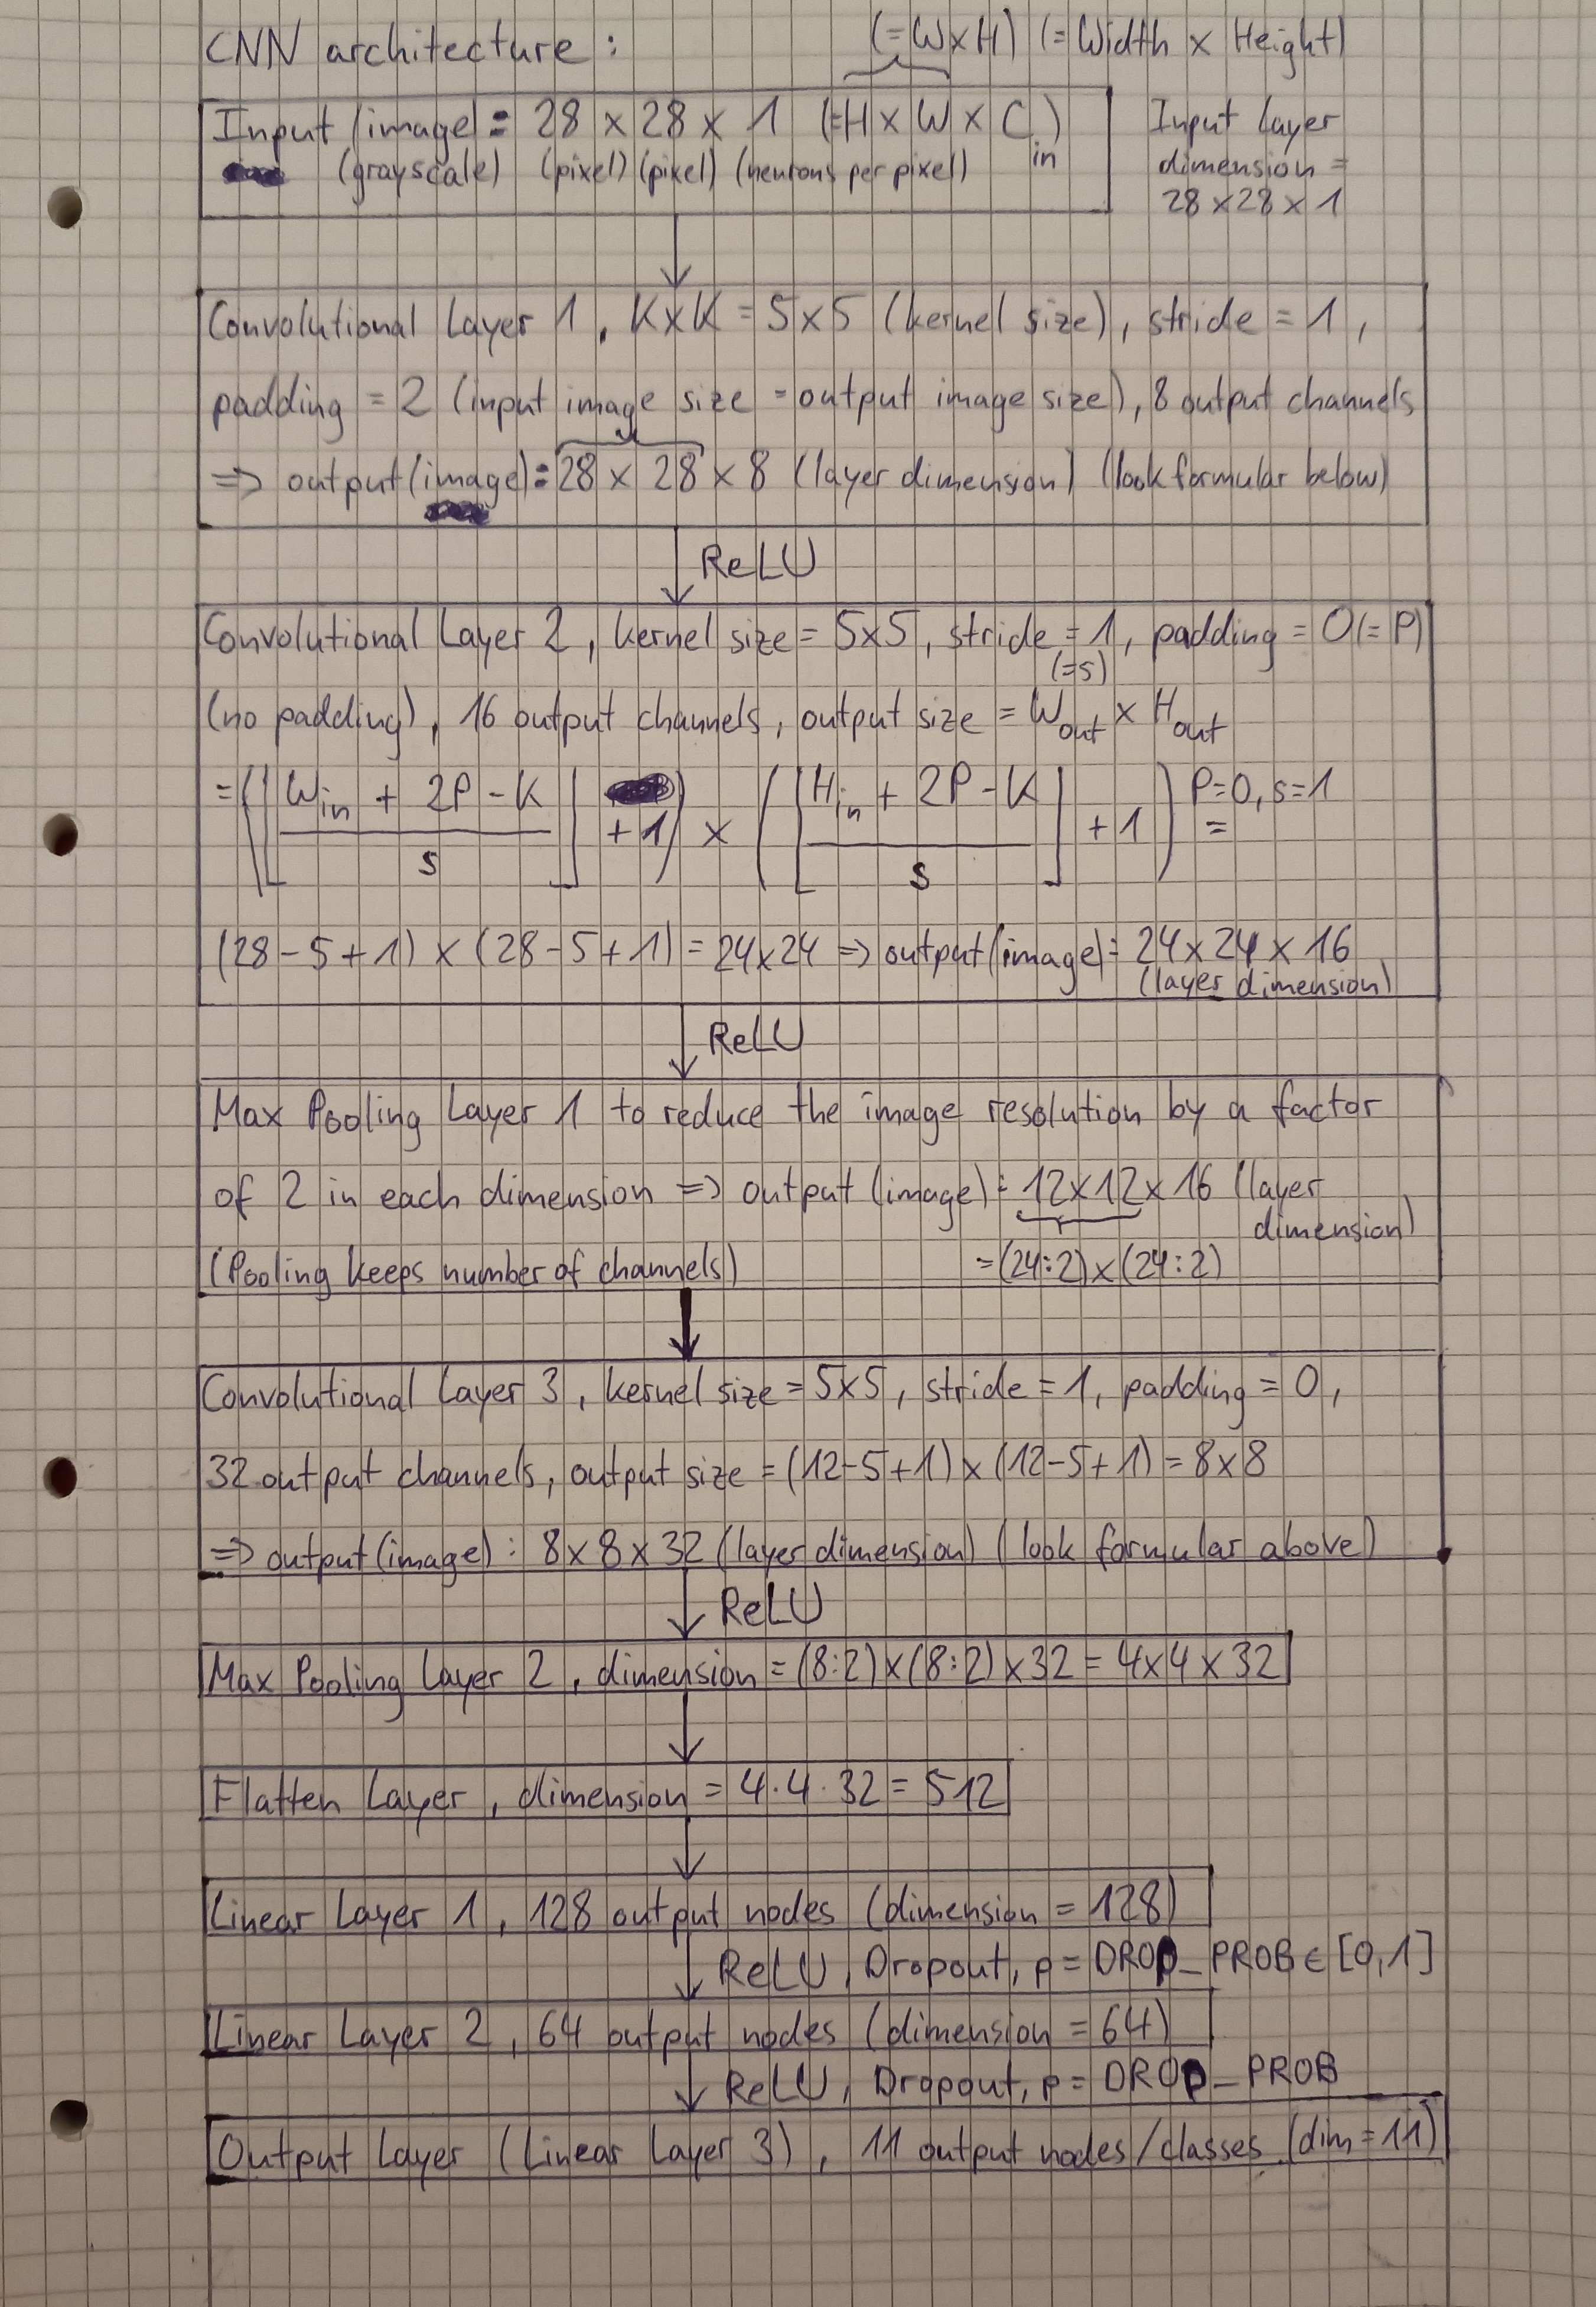
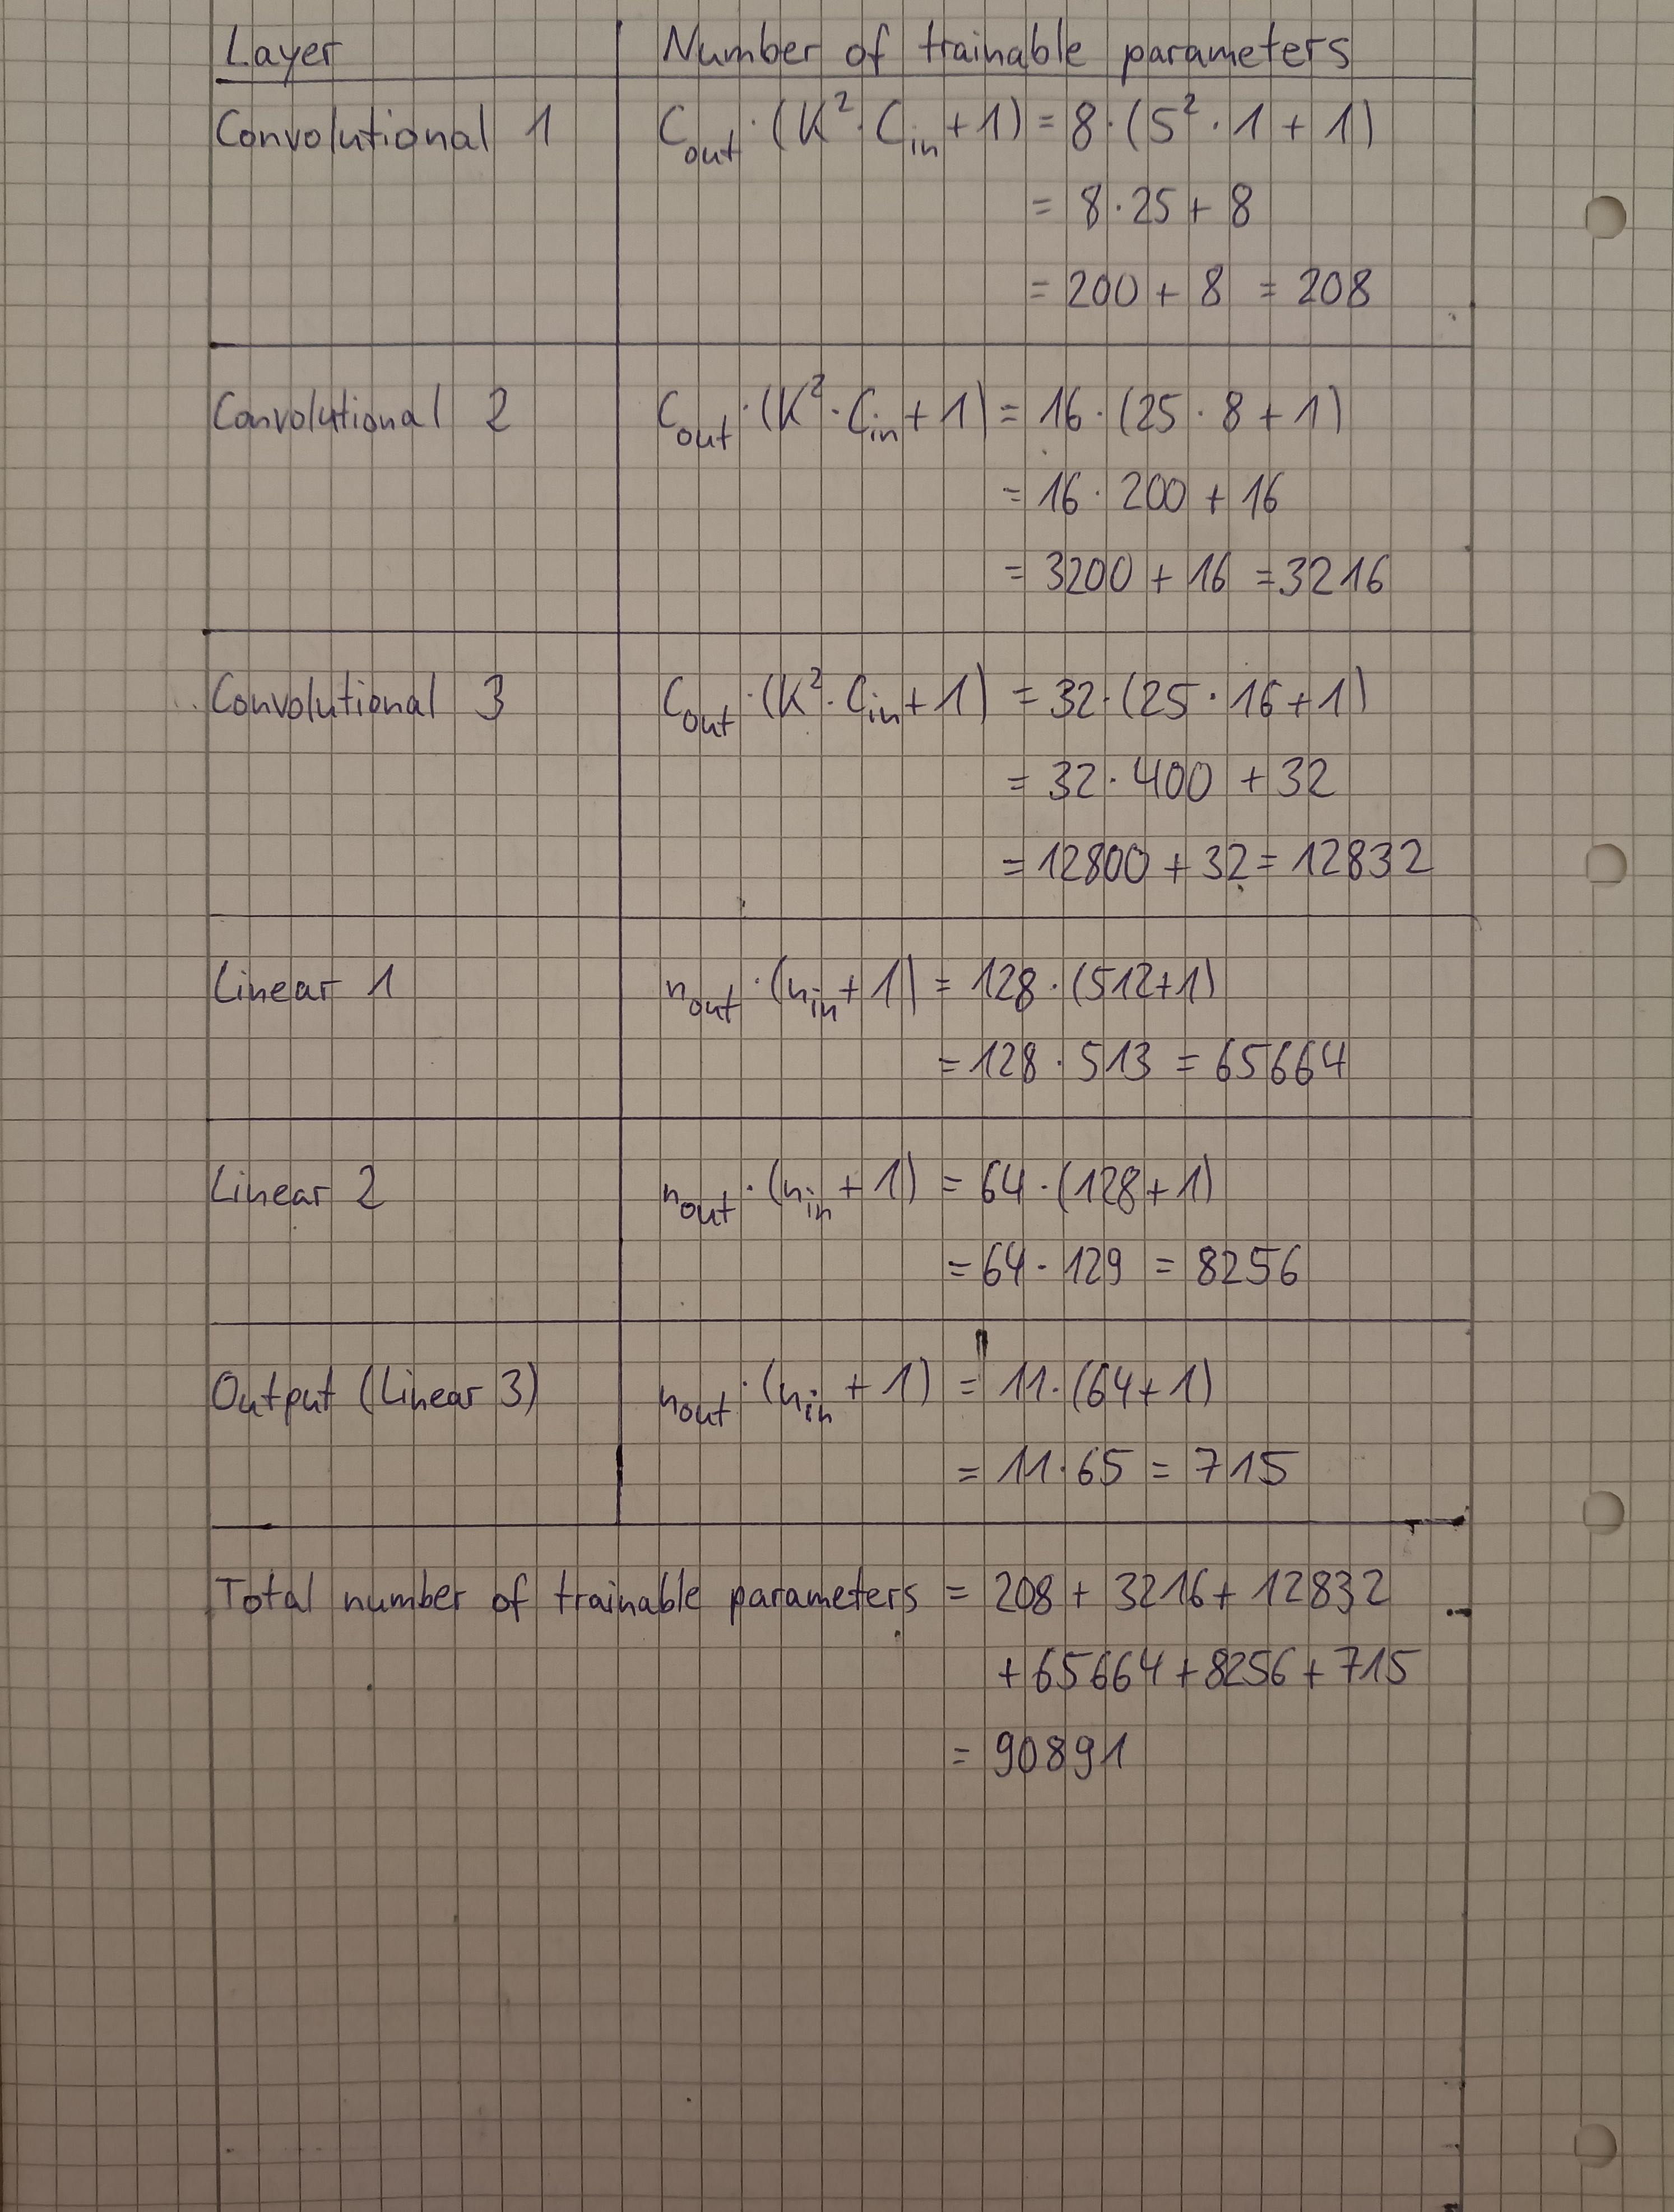

## Task e) Implementation of network architecture 

In [7]:
class CNN(nn.Module):

    def __init__(self, number_of_classes=11, DROP_PROB=0.5):
        super().__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)

        # MaxPooling
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Linear (fully connected) layers
        self.l1 = nn.Linear(32 * 4 * 4, 128)
        self.l2 = nn.Linear(128, 64)
        self.l3 = nn.Linear(64, number_of_classes)

        # Dropout
        self.dropout = nn.Dropout(p=DROP_PROB)

    def forward(self, x):

        # Convolutional layer 1
        x = nn.functional.relu(self.conv1(x))

        # Convolutional layer 2
        x = nn.functional.relu(self.conv2(x))

        # "Maxpooling is applied prior to the input of the 3rd convolutional layer"
        x = self.max_pool(x)

        # Convolutional layer 3
        x = nn.functional.relu(self.conv3(x))

        # "Maxpooling is applied prior to the input of the 1st linear layer"
        x = self.max_pool(x)

        # Flatten
        x = torch.flatten(x, start_dim=1)

        # Linear layer 1
        x = nn.functional.relu(self.l1(x))
        x = self.dropout(x)

        # Linear layer 2
        x = nn.functional.relu(self.l2(x))
        x = self.dropout(x)

        # Output (linear layer 3)
        x = self.l3(x)

        return x
    
model = CNN(number_of_classes=11, DROP_PROB=0.5)
print(model)

CNN(
  (conv1): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (l1): Linear(in_features=512, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=64, bias=True)
  (l3): Linear(in_features=64, out_features=11, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## Task f) Implementation of training algorithm with early stopping

In [ ]:
# "epoch-wise recording of classification accuracy and loss for training dataset during training"
def train_epoch(model, dataloader, cross_entropy_loss, optimizer, device):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = cross_entropy_loss(outputs, labels)
        loss.backward()

        optimizer.step()
        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# "epoch-wise recording of classification accuracy and loss for validation dataset during training" (analog zu oben)
def evaluate(model, dataloader, cross_entropy_loss, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = cross_entropy_loss(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# early stopping regularization
import copy
best_loss = float("inf")
best_weights = None

def train_model(model, train_loader, val_loader, cross_entropy_loss, optimizer, device, max_epochs, PASSED_EPOCHS):

    history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
    best_loss = float("inf")
    best_weights = copy.deepcopy(model.state_dict())
    i = 0

    for epoch in range(max_epochs):

        train_loss, train_accuracy = train_epoch(model, train_loader, cross_entropy_loss, optimizer, device)
        val_loss, val_accuracy = evaluate(model, val_loader, cross_entropy_loss, device)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(f"Epoch {epoch+1:3d} " f"train_loss={train_loss:.4f} " f"train_accuracy={train_accuracy:.4f}  | " f"val_loss={val_loss:.4f} " f"val_accuracy={val_accuracy:.4f}")

        """ During training record the model parameters when the validation loss for the validation dataset
            is lower then the lowest validation loss achieved up to that point in training."""
        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            i = 0

        else:
            i += 1
        # "If the validation loss does not decrease below the minimum for a certain number of epochs (PASSED_EPOCHS), stop the training."
        if i >= PASSED_EPOCHS:
            print("Early stopping")
            break
    # "As final model parameters choose from the record those with which the lowest validation loss is achieved until stopping."
    model.load_state_dict(best_weights)
    return history

## Network / training / hyperparameters  definitions

In [ ]:
# hyperparameters
learning_rate = 1e-4
batch_size = 100
max_epochs = 100
PASSED_EPOCHS = 10

# DataLoader
val_loader = DataLoader(val_dataset, batch_size, shuffle=False)
# "training with randomized minibatches"
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

# network
model = CNN(number_of_classes=11, DROP_PROB=0.5).to(device)

# Adam optimizer
from torch import optim
optimizer = optim.Adam(model.parameters(),lr=learning_rate)

# cross-entropy loss
cross_entropy_loss = nn.CrossEntropyLoss()

## Task g) Network training without dropout

In [ ]:
initial_state = CNN(number_of_classes=11, DROP_PROB=0.0).state_dict()
model = CNN(number_of_classes=11, DROP_PROB=0.0).to(device)
model.load_state_dict(initial_state)

optimizer = optim.Adam(model.parameters(),lr=learning_rate)
history = train_model(model, train_loader, val_loader, cross_entropy_loss, optimizer, device, max_epochs, PASSED_EPOCHS)
torch.save(model.state_dict(),"cnn_without_dropout.pth")

Epoch   1 train_loss=0.9213 train_accuracy=0.7226  | val_loss=0.3752 val_accuracy=0.8897
Epoch   2 train_loss=0.3243 train_accuracy=0.9035  | val_loss=0.2503 val_accuracy=0.9255
Epoch   3 train_loss=0.2305 train_accuracy=0.9318  | val_loss=0.1920 val_accuracy=0.9423
Epoch   4 train_loss=0.1772 train_accuracy=0.9472  | val_loss=0.1564 val_accuracy=0.9533
Epoch   5 train_loss=0.1479 train_accuracy=0.9554  | val_loss=0.1275 val_accuracy=0.9639
Epoch   6 train_loss=0.1276 train_accuracy=0.9624  | val_loss=0.1208 val_accuracy=0.9615
Epoch   7 train_loss=0.1143 train_accuracy=0.9668  | val_loss=0.1039 val_accuracy=0.9697
Epoch   8 train_loss=0.1005 train_accuracy=0.9704  | val_loss=0.0937 val_accuracy=0.9719
Epoch   9 train_loss=0.0924 train_accuracy=0.9728  | val_loss=0.1019 val_accuracy=0.9688
Epoch  10 train_loss=0.0848 train_accuracy=0.9758  | val_loss=0.0851 val_accuracy=0.9755
Epoch  11 train_loss=0.0780 train_accuracy=0.9771  | val_loss=0.0795 val_accuracy=0.9778
Epoch  12 train_loss=

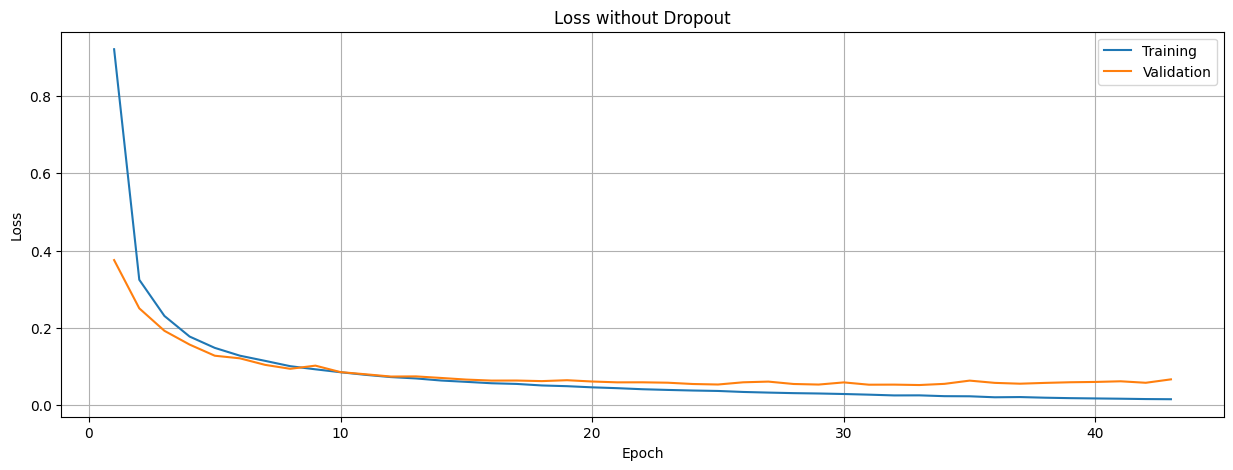

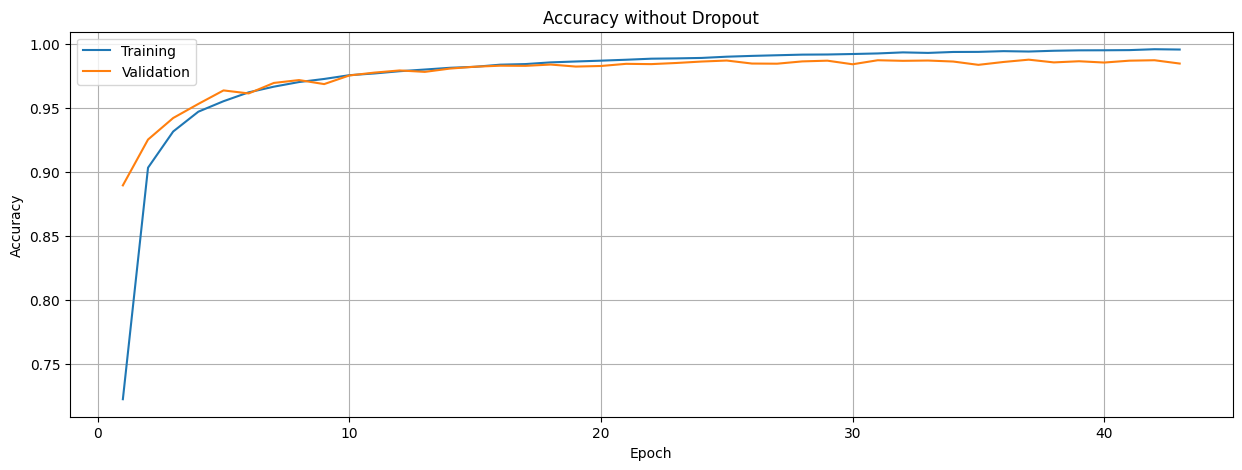

learning rate : 0.0001
minibatch size : 100
PASSED_EPOCHS : 10

Final train_loss : 0.0149
Final train_accuracy : 0.9958
Final val_loss : 0.0663
Final val_accuracy : 0.9848


In [11]:
# figures and final loss/accuracy in separate cell

plt.figure(figsize=(15,5))
plt.plot(range(1,len(history["train_loss"])+1), history["train_loss"], label="Training")
plt.plot(range(1,len(history["val_loss"])+1), history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss without Dropout")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(15,5))
plt.plot(range(1,len(history["train_accuracy"])+1), history["train_accuracy"], label="Training")
plt.plot(range(1,len(history["val_accuracy"])+1), history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy without Dropout")
plt.grid(True)
plt.legend()
plt.show()

print(f"learning rate : {learning_rate}")
print(f"minibatch size : {batch_size}")
print(f"PASSED_EPOCHS : {PASSED_EPOCHS}")
print()
print(f"Final train_loss : {history['train_loss'][-1]:.4f}")
print(f"Final train_accuracy : {history['train_accuracy'][-1]:.4f}")
print(f"Final val_loss : {history['val_loss'][-1]:.4f}")
print(f"Final val_accuracy : {history['val_accuracy'][-1]:.4f}")

## Task h) Network training with dropout

In [ ]:
# "For better comparability of the results of Task g) and Task h) use the same parameter initialization for both tasks."
model = CNN(number_of_classes=11, DROP_PROB=0.5).to(device)
model.load_state_dict(initial_state)

optimizer = optim.Adam(model.parameters(),lr=learning_rate)
history_dropout = train_model(model, train_loader, val_loader, cross_entropy_loss, optimizer, device, max_epochs, PASSED_EPOCHS)
torch.save(model.state_dict(), "cnn_with_dropout.pth")

Epoch   1 train_loss=1.4679 train_accuracy=0.5018  | val_loss=0.4711 val_accuracy=0.8635
Epoch   2 train_loss=0.6738 train_accuracy=0.7930  | val_loss=0.2922 val_accuracy=0.9110
Epoch   3 train_loss=0.4779 train_accuracy=0.8589  | val_loss=0.2146 val_accuracy=0.9336
Epoch   4 train_loss=0.3834 train_accuracy=0.8900  | val_loss=0.1814 val_accuracy=0.9448
Epoch   5 train_loss=0.3266 train_accuracy=0.9076  | val_loss=0.1566 val_accuracy=0.9516
Epoch   6 train_loss=0.2840 train_accuracy=0.9205  | val_loss=0.1406 val_accuracy=0.9607
Epoch   7 train_loss=0.2592 train_accuracy=0.9288  | val_loss=0.1230 val_accuracy=0.9634
Epoch   8 train_loss=0.2305 train_accuracy=0.9368  | val_loss=0.1185 val_accuracy=0.9660
Epoch   9 train_loss=0.2126 train_accuracy=0.9408  | val_loss=0.1055 val_accuracy=0.9708
Epoch  10 train_loss=0.1993 train_accuracy=0.9460  | val_loss=0.1016 val_accuracy=0.9722
Epoch  11 train_loss=0.1884 train_accuracy=0.9495  | val_loss=0.0972 val_accuracy=0.9736
Epoch  12 train_loss=

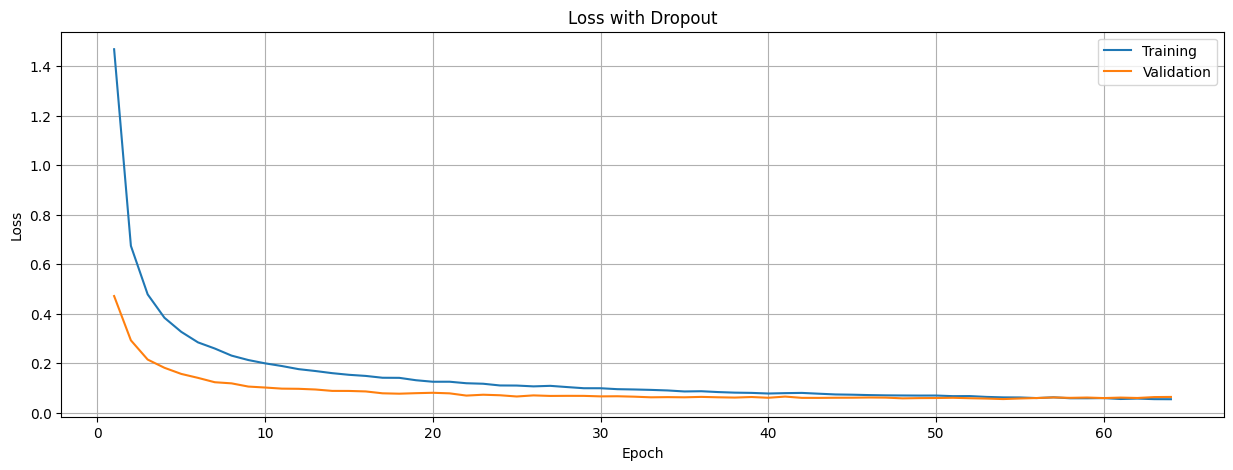

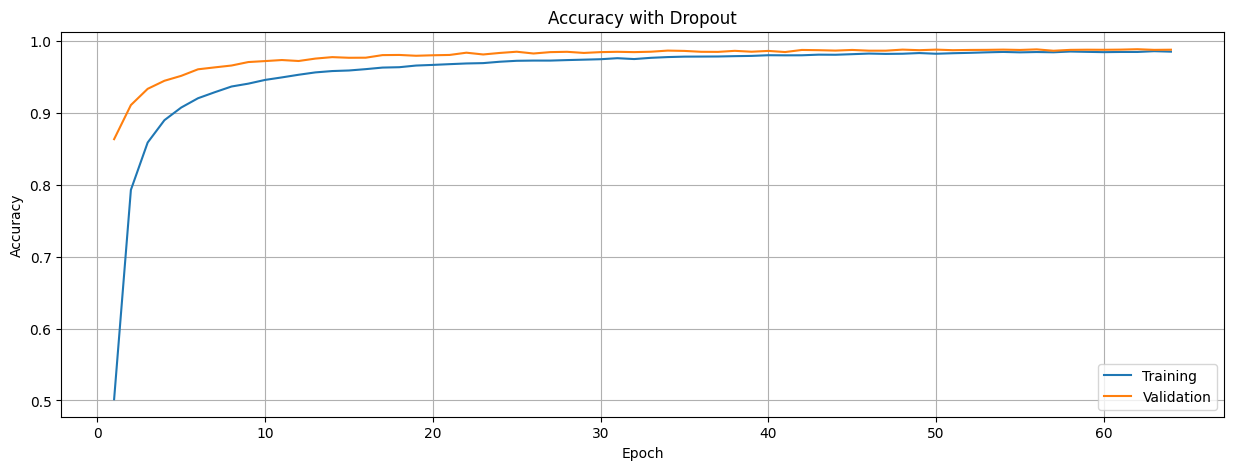

learning rate : 0.0001
minibatch size : 100
PASSED_EPOCHS : 10
DROP_PROB : 0.5

Final train_loss : 0.0544
Final train_accuracy : 0.9853
Final val_loss : 0.0636
Final val_accuracy : 0.9880


In [13]:
# figures and final loss/accuracy in separate cell

plt.figure(figsize=(15,5))
plt.plot(range(1,len(history_dropout["train_loss"])+1), history_dropout["train_loss"], label="Training")
plt.plot(range(1,len(history_dropout["val_loss"])+1), history_dropout["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss with Dropout")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(15,5))
plt.plot(range(1,len(history_dropout["train_accuracy"])+1), history_dropout["train_accuracy"], label="Training")
plt.plot(range(1,len(history_dropout["val_accuracy"])+1), history_dropout["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy with Dropout")
plt.grid(True)
plt.legend()
plt.show()

print(f"learning rate : {learning_rate}")
print(f"minibatch size : {batch_size}")
print(f"PASSED_EPOCHS : {PASSED_EPOCHS}")
print(f"DROP_PROB : 0.5")
print()
print(f"Final train_loss : {history_dropout['train_loss'][-1]:.4f}")
print(f"Final train_accuracy : {history_dropout['train_accuracy'][-1]:.4f}")
print(f"Final val_loss : {history_dropout['val_loss'][-1]:.4f}")
print(f"Final val_accuracy : {history_dropout['val_accuracy'][-1]:.4f}")

#### Discussion/comparison of results in g) / h) and effect of dropout
Wie zu erwarten hat das CNN mit Dropout zum Schluss eine etwas höhere Validierungsgenauigkeit und eine etwas niedrigere Trainingsgenauigkeit als das CNN ohne Dropout erreicht. Die geringere Trainingsgenauigkeit beim CNN mit Dropout resultiert aus der zufälligen Deaktivierung einzelner Neuronen und der damit einhergehenden geringeren Komplexität des Netzwerks. Durch die Anwendung von Dropout wird verhindert, dass sich das CNN zu stark auf bestimmte einzelne Neuronen verlässt, wodurch es besser für die nicht zuvor gesehenen Validierungsdaten funktioniert.

## Task i) Re-loading of model saved in h)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CNN(nn.Module):

    def __init__(self, number_of_classes=11, DROP_PROB=0.5):
        super().__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)

        # MaxPooling
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Linear (fully connected) layers
        self.l1 = nn.Linear(32 * 4 * 4, 128)
        self.l2 = nn.Linear(128, 64)
        self.l3 = nn.Linear(64, number_of_classes)

        # Dropout
        self.dropout = nn.Dropout(p=DROP_PROB)

    def forward(self, x):

        # Convolutional layer 1
        x = nn.functional.relu(self.conv1(x))

        # Convolutional layer 2
        x = nn.functional.relu(self.conv2(x))

        # "Maxpooling is applied prior to the input of the 3rd convolutional layer"
        x = self.max_pool(x)

        # Convolutional layer 3
        x = nn.functional.relu(self.conv3(x))

        # "Maxpooling is applied prior to the input of the 1st linear layer"
        x = self.max_pool(x)

        # Flatten
        x = torch.flatten(x, start_dim=1)

        # Linear layer 1
        x = nn.functional.relu(self.l1(x))
        x = self.dropout(x)

        # Linear layer 2
        x = nn.functional.relu(self.l2(x))
        x = self.dropout(x)

        # Output (linear layer 3)
        x = self.l3(x)

        return x   

model_loaded = CNN(number_of_classes=11, DROP_PROB=0.5).to(device)
model_loaded.load_state_dict(torch.load("cnn_with_dropout.pth", map_location=device))
model_loaded.eval()

CNN(
  (conv1): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (l1): Linear(in_features=512, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=64, bias=True)
  (l3): Linear(in_features=64, out_features=11, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

## Task j) Illustration of prediction results via confusion matrix

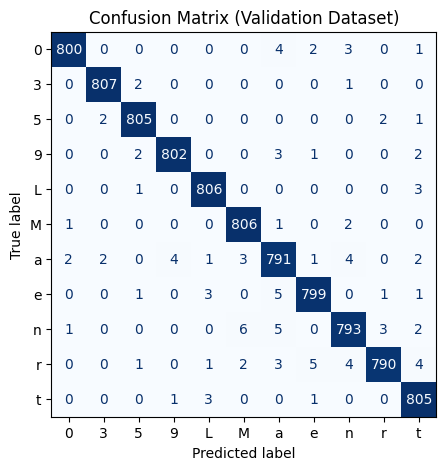

In [ ]:
true_labels = []
predicted_labels = []
model_loaded.eval()

# read EMNIST test/validation data
val_data = datasets.EMNIST(
    root='./data/', # path of EMNIST data
    #split="letters",
    split="byclass",
    train=False,
    download=False,
    transform=ToTensor())

from torch.utils.data import Subset

selected_symbols = ['0', '3', '5', '9', 'L', 'M', 'a', 'e', 'n', 'r', 't']
selected_classes = [0, 3, 5, 9, 21, 22, 36, 40, 49, 53, 55]
label_map = {old: new for new, old in enumerate(selected_classes)}

val_targets = val_data.targets
val_indices = {}
val_counts = {}

for c in selected_classes:
    idx = (val_targets == c).nonzero(as_tuple=True)[0]
    val_indices[c] = idx
    val_counts[c] = len(idx)

min_val = min(val_counts.values())
balanced_val_indices = []

for c in selected_classes:
    balanced_val_indices.extend(val_indices[c][:min_val])

balanced_val = Subset(val_data, balanced_val_indices)

from torch.utils.data import Dataset

class RelabeledDataset(Dataset):

    def __init__(self, subset, label_map):
        self.subset = subset
        self.label_map = label_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return image, self.label_map[label]

val_dataset = RelabeledDataset(balanced_val, label_map)
learning_rate = 1e-4
batch_size = 100
max_epochs = 100
PASSED_EPOCHS = 10
val_loader = DataLoader(val_dataset, batch_size, shuffle=False)

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)
        outputs = model_loaded(images)
        predictions = outputs.argmax(dim=1)
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predictions.cpu().numpy())

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=selected_symbols)
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Confusion Matrix (Validation Dataset)")
plt.show()

## Task k) Visualization of most frequent misclassifications for chosen class

True class : 0
Most predicted : a
Number of errors : 4


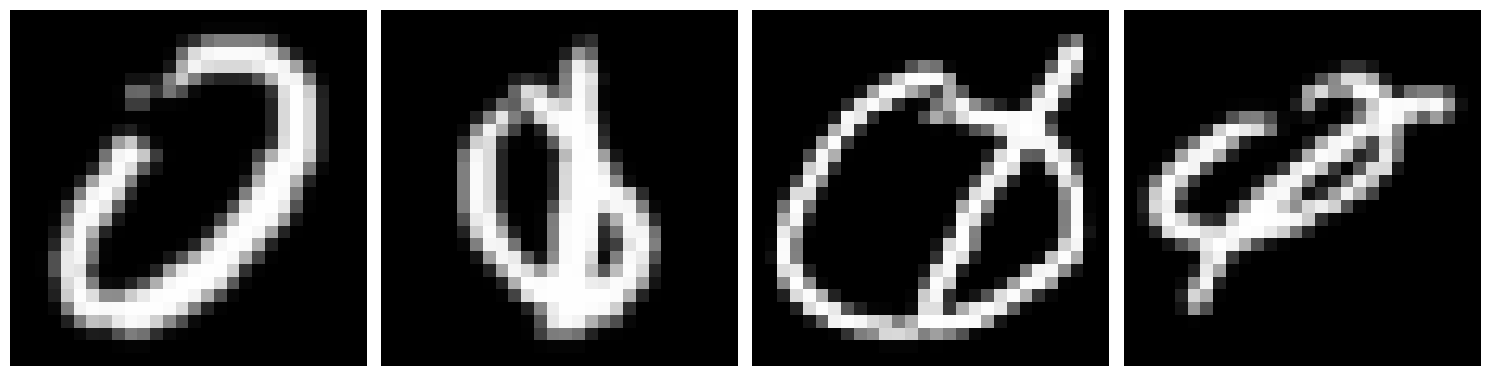

True class : 3
Most predicted : 5
Number of errors : 2


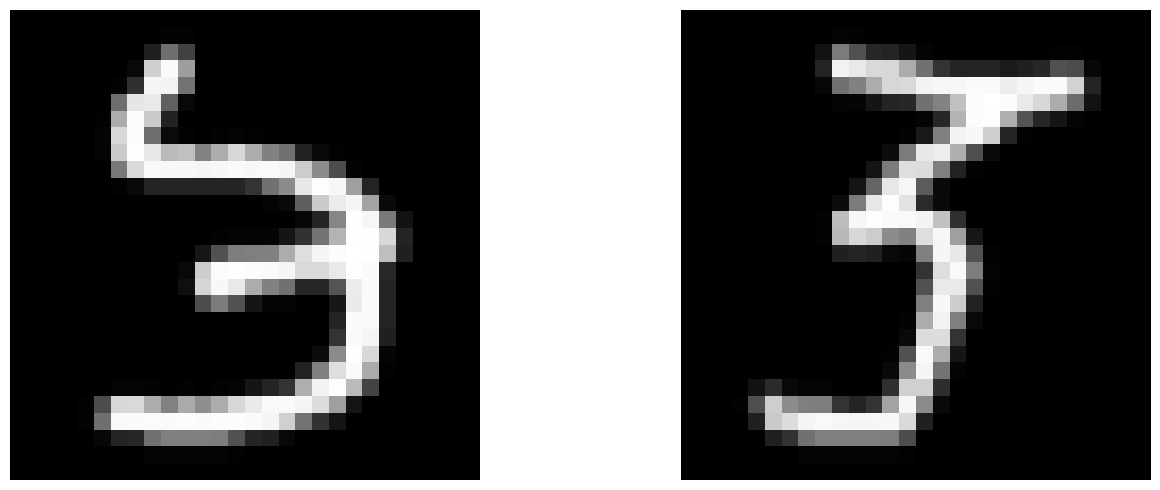

True class : 5
Most predicted : 3
Number of errors : 2


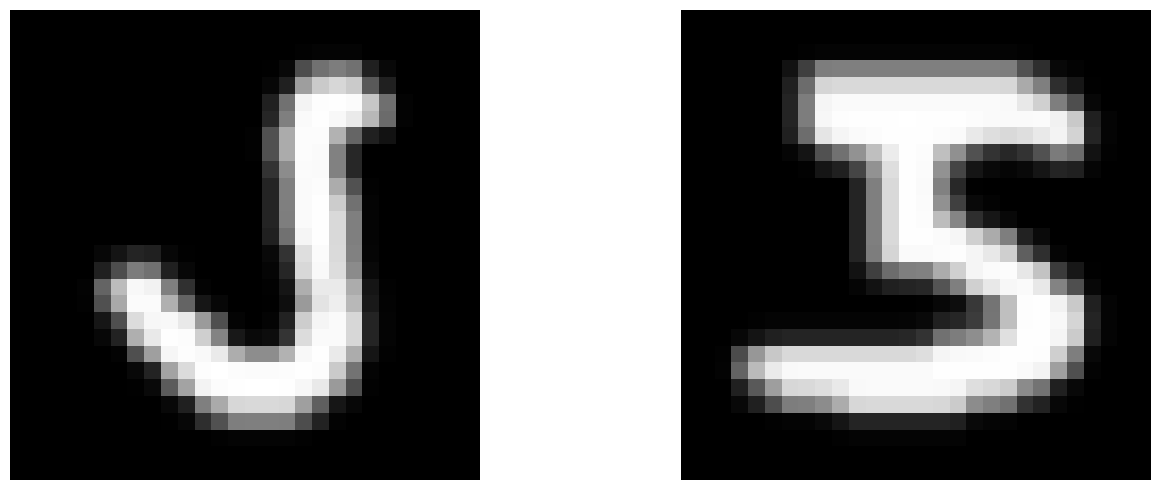

True class : 9
Most predicted : a
Number of errors : 3


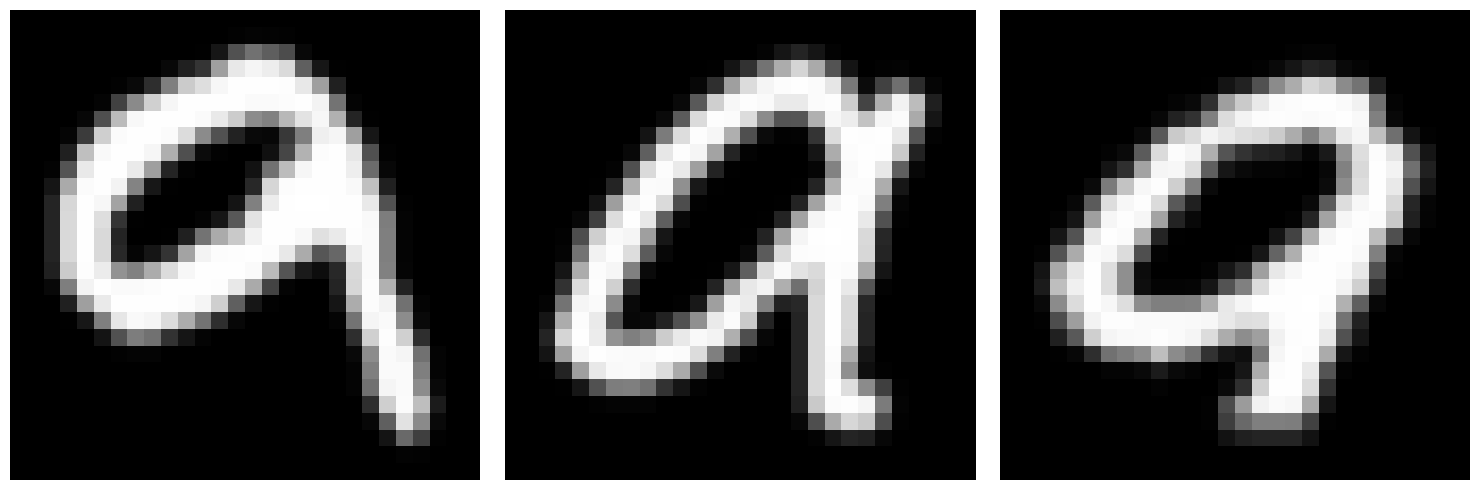

True class : L
Most predicted : t
Number of errors : 3


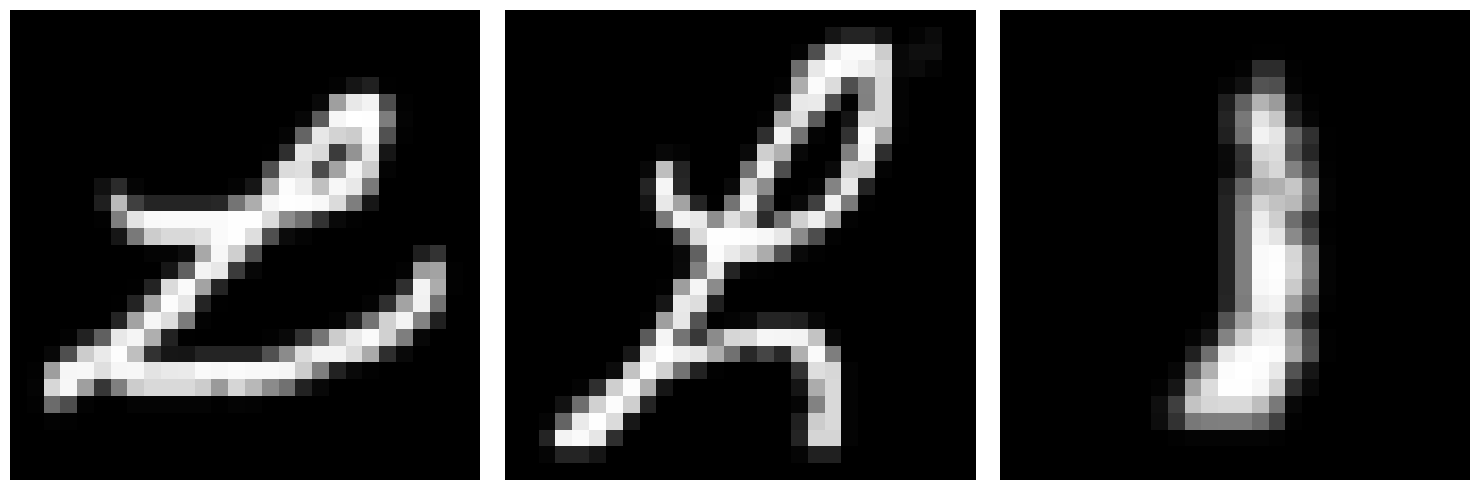

True class : M
Most predicted : n
Number of errors : 2


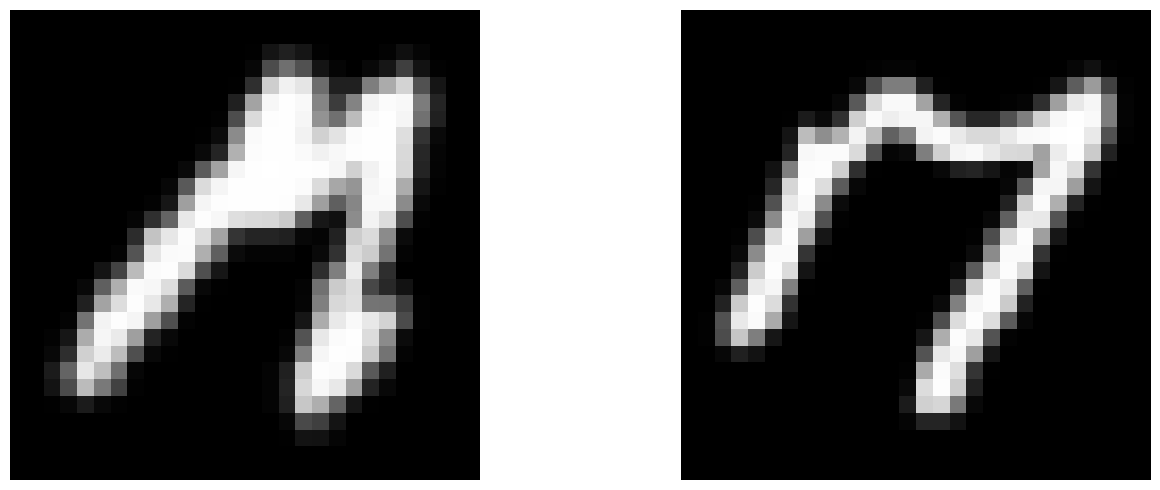

True class : a
Most predicted : 9
Number of errors : 4


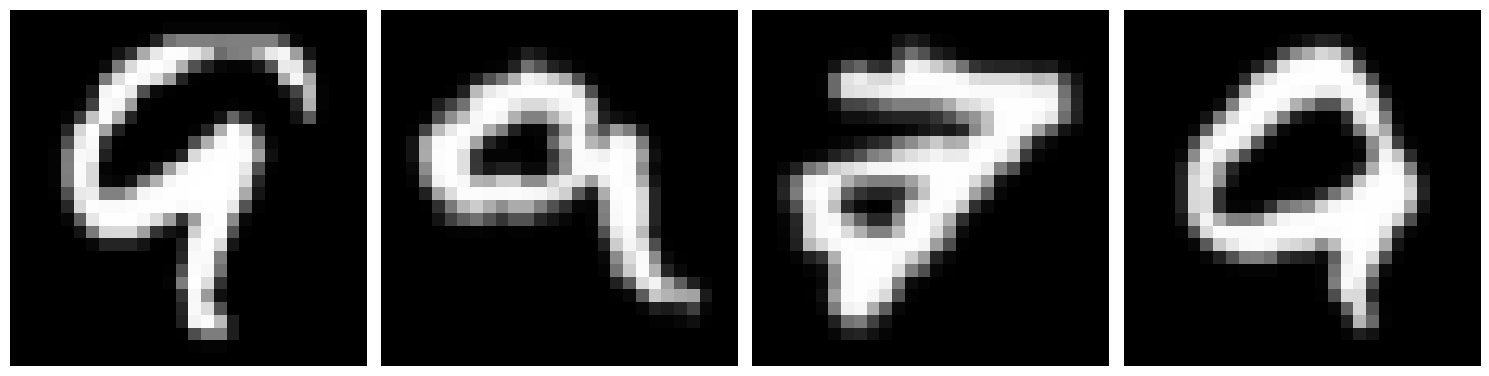

True class : e
Most predicted : a
Number of errors : 5


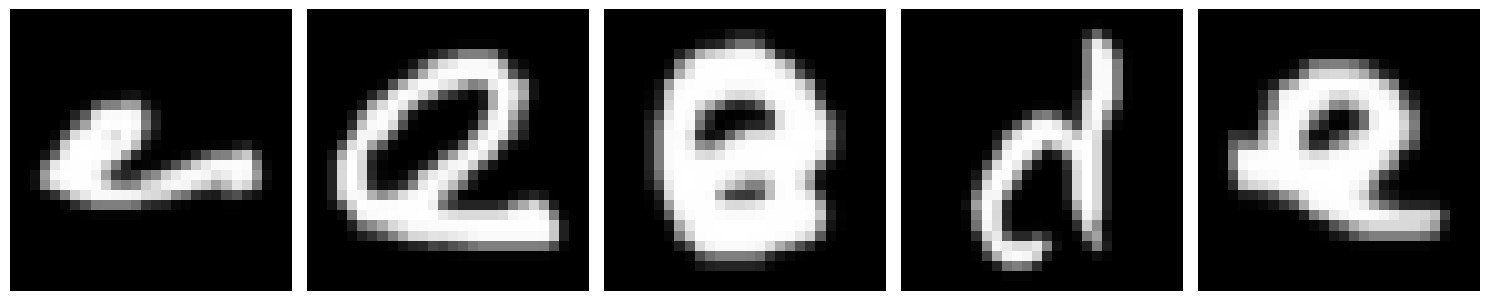

True class : n
Most predicted : M
Number of errors : 6


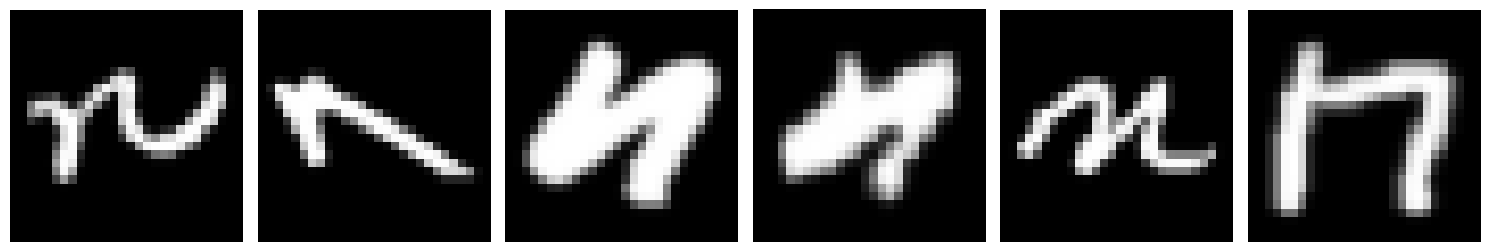

True class : r
Most predicted : e
Number of errors : 5


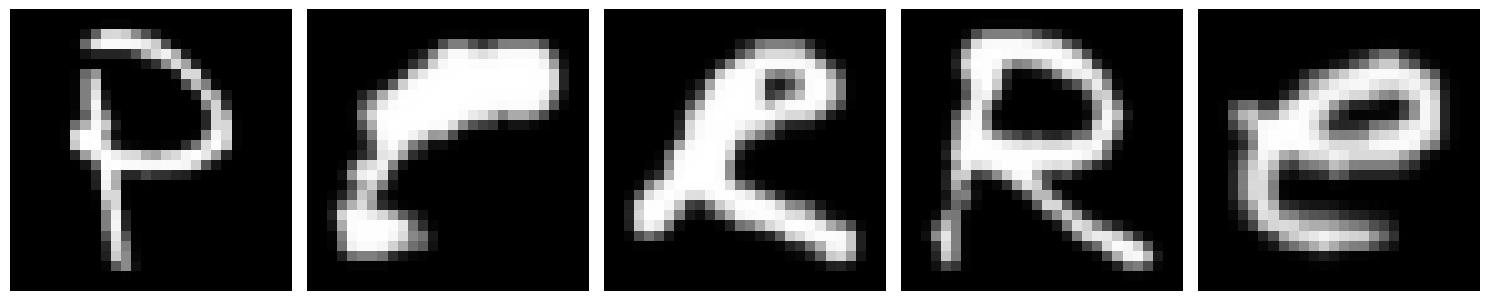

True class : t
Most predicted : L
Number of errors : 3


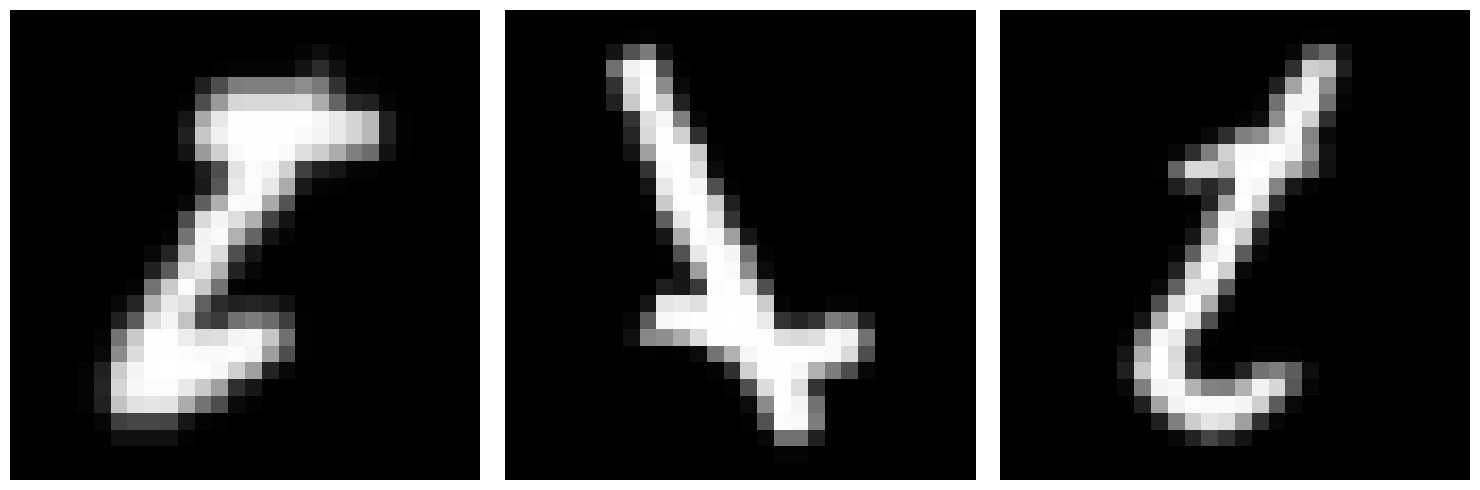

In [4]:
def analyze_misclassifications(model, dataloader, device, true_class, class_names, max_images=10):

    images_list = []
    predicted_list = []
    model.eval()

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1).cpu()

            for img, true_label, pred_label in zip(images.cpu(), labels, predictions):

                if true_label == true_class and pred_label != true_class:

                    images_list.append(img)
                    predicted_list.append(pred_label.item())

    if len(predicted_list) == 0:

        print(f"No misclassifications for this class.")
        return

    # "The function should determine for the (training or testing/validation) dataset and a specified (true) class label the most frequently misclassified predicted class."
    counts = torch.bincount(torch.tensor(predicted_list), minlength=len(class_names))
    most_common_prediction = torch.argmax(counts).item()
    print(f"True class : {class_names[true_class]}")
    print(f"Most predicted : {class_names[most_common_prediction]}")
    print(f"Number of errors : {counts[most_common_prediction].item()}")

    # "The function should allow to visualize a selection of images of these misclassifcations with the true and the predicted letter/digit labels as image captions."
    selected_images = []

    for img, pred in zip(images_list, predicted_list):

        if pred == most_common_prediction:
            selected_images.append(img)

    n = min(max_images, len(selected_images))
    plt.figure(figsize=(15,5))

    for i in range(n):

        plt.subplot(1, n, i+1)
        image = selected_images[i].squeeze()

        # "Note: To display the images of the considered dataset correctly they need to be ’transposed’ (horizontal flip and then 90-degrees-anti-clockwise rotation)."
        image = torch.rot90(torch.fliplr(image), k=1)

        plt.imshow(image, cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

for i in range(11):
    analyze_misclassifications(model_loaded, val_loader, device, true_class=i, class_names=selected_symbols)

#### Discussion of missclassification results
Die dargestellten Fehlklassifikationen sind menschlich nachvollziehbar, da bestimmte handschriftlich geschriebene Buchstaben und Zahlen ähnlich aussehen. Mit einer Validierungsgenauigkeit von fast 99% treten Fehlklassifikationen jedoch nur selten auf.

## Task l) t-SNE embedding of linear layer feature vectors

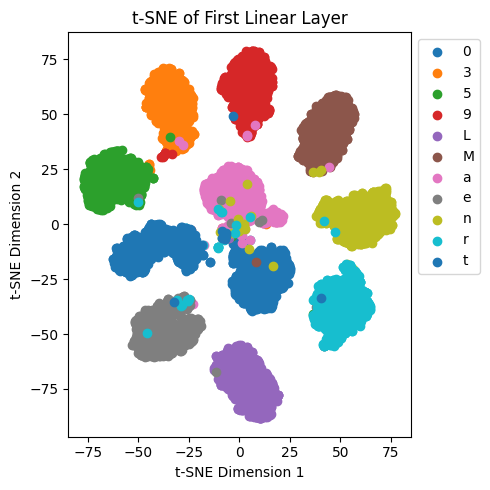

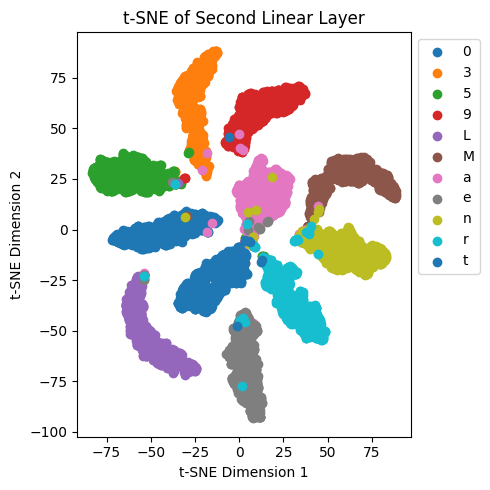

In [5]:
def extract_features(model, dataloader, device):

    model.eval()

    feature_l1 = []
    feature_l2 = []
    labels_all = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            # Convolutional layer 1
            x = nn.functional.relu(model.conv1(images))

            # Convolutional layer 2
            x = nn.functional.relu(model.conv2(x))

            # Max pooling 1
            x = model.max_pool(x)

            # Convolutional layer 3
            x = nn.functional.relu(model.conv3(x))

            # Max pooling 2
            x = model.max_pool(x)

            # Flatten
            x = torch.flatten(x, start_dim=1)

            # Linear layer 1
            x = nn.functional.relu(model.l1(x))
            feature_l1.append(x.cpu())

            # Dropout
            x = model.dropout(x)

            # Linear layer 2
            x = nn.functional.relu(model.l2(x))
            feature_l2.append(x.cpu())

            labels_all.append(labels)

    feature_l1 = torch.cat(feature_l1).numpy()
    feature_l2 = torch.cat(feature_l2).numpy()
    labels_all = torch.cat(labels_all).numpy()

    return feature_l1, feature_l2, labels_all

l1_feature, l2_feature, labels = extract_features(model_loaded, val_loader, device)

# "Apply the t-distributed stochastic neighbor embedding (t-SNE) method to embed the set of feature vectors into a 2-dimensional space."
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedding_l1 = tsne.fit_transform(l1_feature)
embedding_l2 = tsne.fit_transform(l2_feature)


def plot_tsne(embedding, labels, class_names, title):

    plt.figure(figsize=(5,5))

    for i, name in enumerate(class_names):

        idx = labels == i
        plt.scatter(embedding[idx,0], embedding[idx,1], label=name)

    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(bbox_to_anchor=(1,1))
    plt.tight_layout()
    plt.show()

plot_tsne(embedding_l1, labels, selected_symbols, "t-SNE of First Linear Layer")
plot_tsne(embedding_l2, labels, selected_symbols, "t-SNE of Second Linear Layer")

#### Discussion of feature vector embedding
Die t-SNE-Darstellung der Feature-Vektoren zeigt, dass sich samples, die zur selben Klasse gehören, zu voneinander abgrenzenden Clustern gruppieren. Während sich für die erste lineare Schicht nahezu kreisförmige Cluster bilden, sind die Cluster für die zweite lineare Schicht bereits schmaler und in die Länge gezogen, d.h. die tiefere der beiden Schichten kann die einzelnen Klassen besser voneinander unterscheiden. Zwischen einigen Clustern ist weiterhin eine geringe Überlappung erkennbar, was auf die einzelnen wenigen Fehlklassifikationen zurückzuführen ist. 

## Task m) (Extra task) Reduction of CNN complexity

In [ ]:
# "Find a CNN architecture with at least 40% fewer trainable parameters, which achieves the same validation classification accuracy as your optimized model in Task h)."
# total number of trainable parameters = 90891 (siehe Aufgabe d)
# Somit darf das neue CNN höchstens insgesamt 54534 < 54534.6 = 90891*0.6 < 54535 trainierbare Parameter besitzen.

# Von den 90891 trainierbaren Parametern liegen die meisten im Linear Layer 1, nämlich 65664, also 65664/90891 = 0.722 = 72.2 % der gesamten trainierbaren Parameter.
# Somit muss die Parameteranzahl für die erste lineare Schicht auf jeden Fall reduziert werden, um eine Gesamtreduzierung von mind. 40% überhaupt erst erreichen zu können.
# Die Parameteranzahl im First Linear Layer kommt vor allem durch den Input zustande, denn: 65664 = 128 * 513 = 128*(512+1) = n_out*(n_in + 1) , vgl. Aufgabe d)
# Somit müsste vor allem die Dimension n_in = 512 des Flatten Layers reduziert werden. Dazu müsste man die Dimension des dritten Convolutional Layers reduzieren (8x8x32).
# Da bei Anwendung von Max Pooling die Anzahl von output channels (32) erhalten bleibt, sollte die Anzahl von output channels im Convolutional Layer 3 manuell reduziert werden.
# Gleichzeitig sollte man auch die Anzahl der Output-Knoten n_out = 128 des First Linear Layers deutlich reduzieren."""

class CNN_reduced(nn.Module):

    # Da die Anzahl an output nodes in den ersten beiden Linear Layers bereits manuell reduziert wird, verwende kleinere dropout probability.
    def __init__(self, number_of_classes=11, DROP_PROB=0.3):

        super().__init__()

        # Convolutional Layer 1 (unverändert, nur 208 trainierbare Parameter)
        self.conv1 = nn.Conv2d(1,8,5,padding=2)

        # Convolutional Layer 2 (nur noch 15 output channels statt 16)
        self.conv2 = nn.Conv2d(8,15,5)

        # Convolutional Layer 3 (nur noch 28 output channels statt 32 und 15 input channels statt 16)
        self.conv3 = nn.Conv2d(15,28,5)

        # Max Pooling
        self.max_pool = nn.MaxPool2d(2)

        # Linear Layer 1 (nur noch 82 output nodes statt 128 und 28*4*4=448 input nodes statt 32*4*4=512)
        self.l1 = nn.Linear(28*4*4,82)

        # Linear Layer 2 (nur noch 42 output nodes statt 64)
        self.l2 = nn.Linear(82,42)

        # Linear Layer 3 (nur noch 42 input nodes)
        self.l3 = nn.Linear(42,number_of_classes)

        # Dropout
        self.dropout = nn.Dropout(DROP_PROB)

    def forward(self,x):
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.relu(self.conv2(x))
        x = self.max_pool(x)
        x = nn.functional.relu(self.conv3(x))
        x = self.max_pool(x)
        x = torch.flatten(x,1)
        x = nn.functional.relu(self.l1(x))
        x = self.dropout(x)
        x = nn.functional.relu(self.l2(x))
        x = self.dropout(x)

        return self.l3(x)
    
model = CNN_reduced(number_of_classes=11, DROP_PROB=0.25).to(device)

# read EMNIST training data
train_data = datasets.EMNIST(
    root= './data/', # path of EMNIST data
    #split="letters",
    split="byclass",
    train=True,
    download=False,
    transform=ToTensor())

train_targets = train_data.targets
train_indices = {}
train_counts = {}

for c in selected_classes:
    idx = (train_targets == c).nonzero(as_tuple=True)[0]
    train_indices[c] = idx
    train_counts[c] = len(idx)

min_train = min(train_counts.values())
balanced_train_indices = []

for c in selected_classes:
    balanced_train_indices.extend(train_indices[c][:min_train])

balanced_train = Subset(train_data, balanced_train_indices)
train_dataset = RelabeledDataset(balanced_train, label_map)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

from torch import optim

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
cross_entropy_loss = nn.CrossEntropyLoss()

def train_epoch(model, dataloader, cross_entropy_loss, optimizer, device):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = cross_entropy_loss(outputs, labels)
        loss.backward()

        optimizer.step()
        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

def evaluate(model, dataloader, cross_entropy_loss, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = cross_entropy_loss(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

import copy
best_loss = float("inf")
best_weights = None

def train_model(model, train_loader, val_loader, cross_entropy_loss, optimizer, device, max_epochs, PASSED_EPOCHS):

    history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
    best_loss = float("inf")
    best_weights = copy.deepcopy(model.state_dict())
    i = 0

    for epoch in range(max_epochs):

        train_loss, train_accuracy = train_epoch(model, train_loader, cross_entropy_loss, optimizer, device)
        val_loss, val_accuracy = evaluate(model, val_loader, cross_entropy_loss, device)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(f"Epoch {epoch+1:3d} " f"train_loss={train_loss:.4f} " f"train_accuracy={train_accuracy:.4f}  | " f"val_loss={val_loss:.4f} " f"val_accuracy={val_accuracy:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            i = 0

        else:
            i += 1

        if i >= PASSED_EPOCHS:
            print("Early stopping")
            break

    model.load_state_dict(best_weights)
    return history

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("total amount of trainable parameters: ", count_parameters(model), "< 54535")
history_reduced = train_model(model, train_loader, val_loader, cross_entropy_loss, optimizer, device, max_epochs, PASSED_EPOCHS)
torch.save(model.state_dict(), "cnn_reduced.pth")

total amount of trainable parameters:  54528 < 54535
Epoch   1 train_loss=1.3466 train_accuracy=0.5543  | val_loss=0.4427 val_accuracy=0.8700
Epoch   2 train_loss=0.5614 train_accuracy=0.8304  | val_loss=0.2911 val_accuracy=0.9140
Epoch   3 train_loss=0.4117 train_accuracy=0.8772  | val_loss=0.2153 val_accuracy=0.9343
Epoch   4 train_loss=0.3279 train_accuracy=0.9034  | val_loss=0.1761 val_accuracy=0.9446
Epoch   5 train_loss=0.2713 train_accuracy=0.9193  | val_loss=0.1459 val_accuracy=0.9572
Epoch   6 train_loss=0.2308 train_accuracy=0.9318  | val_loss=0.1266 val_accuracy=0.9593
Epoch   7 train_loss=0.2061 train_accuracy=0.9396  | val_loss=0.1219 val_accuracy=0.9626
Epoch   8 train_loss=0.1867 train_accuracy=0.9443  | val_loss=0.1022 val_accuracy=0.9684
Epoch   9 train_loss=0.1677 train_accuracy=0.9513  | val_loss=0.0967 val_accuracy=0.9704
Epoch  10 train_loss=0.1563 train_accuracy=0.9546  | val_loss=0.0930 val_accuracy=0.9730
Epoch  11 train_loss=0.1488 train_accuracy=0.9570  | val_